In [76]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/train.csv
/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/test.csv


# Import Libraries :

In [120]:
import numpy as np # linear algebra
import pandas as pd 
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# pre-processing
from sklearn.compose import ColumnTransformer
# Imputation
from sklearn.impute import SimpleImputer
# Pipeline
from sklearn.pipeline import Pipeline
# Categorical Columns
from sklearn.preprocessing import OneHotEncoder
# Scaling
from sklearn.preprocessing import StandardScaler
# train-test-split
from sklearn.model_selection import train_test_split
# Logistic regression
from sklearn.linear_model import LogisticRegression
# Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, 
classification_report

In [78]:
train_set = pd.read_csv("/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/train.csv")
test_set = pd.read_csv("/kaggle/input/datasets/rishabhdevadiga/titanic-dataset/test.csv")

# Data Inspection :

In [79]:
train_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [80]:
train_set.shape

(891, 12)

In [81]:
train_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [82]:
train_set.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

# Exploratory Data Analysis :

In [83]:
train_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [84]:
test_set.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [85]:
train_set['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

- 549 - Non Survived
- 342 - Survived

## Pclass :

In [86]:
#print percentage of people who survived by pclass
print("Percentage of Pclass = 1 who survived:", train_set['Survived'][train_set
      ['Pclass'] == 1].value_counts(normalize = True)[1] * 100)

print("Percentage of Pclass = 2 who survived:", train_set['Survived'][train_set
      ['Pclass'] == 2].value_counts(normalize = True)[1] * 100)

print("Percentage of Pclass = 3 who survived:", train_set['Survived'][train_set
      ['Pclass'] == 3].value_counts(normalize = True)[1] * 100)

Percentage of Pclass = 1 who survived: 62.96296296296296
Percentage of Pclass = 2 who survived: 47.28260869565217
Percentage of Pclass = 3 who survived: 24.236252545824847


<Axes: xlabel='Survived', ylabel='count'>

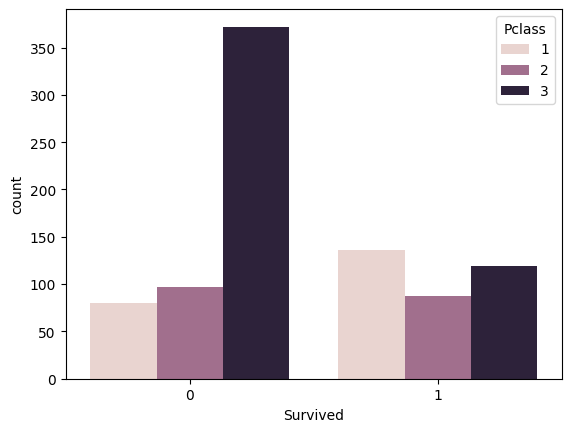

In [87]:
sns.countplot(data = train_set, x = "Survived", hue = "Pclass")

## Gender :

Count of females who survived: 233
Count of females who did not survive: 81
--------------------------------------------
Count of males who survived: 109
Count of males who did not survive: 468


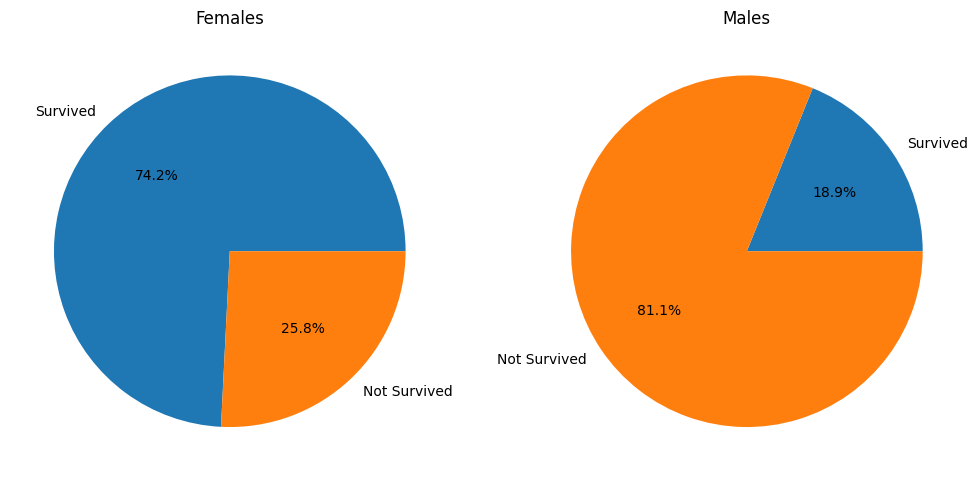

In [88]:
#Count of females who survived and who didnt

female_survived_count = train_set[(train_set['Sex'] == 'female') & (train_set['Survived'] == 1)].shape[0]
female_not_survived_count = train_set[(train_set['Sex'] == 'female') & (train_set['Survived'] == 0)].shape[0]

#Count of males who survived and who didnt
male_survived_count = train_set[(train_set['Sex'] == 'male') & (train_set['Survived'] == 1)].shape[0]
male_not_survived_count = train_set[(train_set['Sex'] == 'male') & (train_set['Survived'] == 0)].shape[0]

print("Count of females who survived:", female_survived_count)
print("Count of females who did not survive:", female_not_survived_count)
print("--------------------------------------------")
print("Count of males who survived:", male_survived_count)
print("Count of males who did not survive:", male_not_survived_count)

#Pie plot for females

plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
labels = ['Survived', 'Not Survived']
Sizes = [female_survived_count, female_not_survived_count]
plt.pie(Sizes, labels=labels, autopct = '%1.1f%%')
plt.title('Females')

#Pie plot for males

plt.subplot(1,2,2)
Sizes = [male_survived_count, male_not_survived_count]
plt.pie(Sizes, labels=labels, autopct = '%1.1f%%')
plt.title('Males')

plt.tight_layout()
plt.show()

## Age Groups :

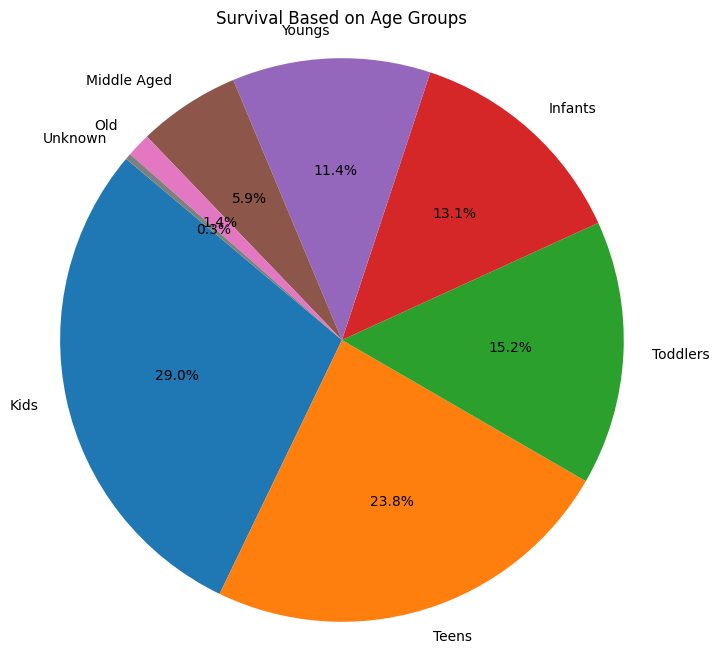

In [89]:
# Assuming train_set contains the necessary data

# Define age groups
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ['Infants', 'Toddlers', 'Kids', 'Teens', 'Youngs', 'Middle Aged', 'Old', 'Unknown']  # Add 'Unknown' for values outside the defined bins
# Categorize ages into groups
train_set['AgeGroup'] = pd.cut(train_set['Age'], bins=age_bins, labels=age_labels)

# Count survivors in each age group
survivors_by_age_group = train_set[train_set['Survived'] == 1]['AgeGroup'].value_counts()
# test data
# Define age groups
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ['Infants', 'Toddlers', 'Kids', 'Teens', 'Youngs', 'Middle Aged', 'Old', 'Unknown']  # Add 'Unknown' for values outside the defined bins
# Categorize ages into groups
test_set['AgeGroup'] = pd.cut(test_set['Age'], bins=age_bins, labels=age_labels)

# Count survivors in each age group
survivors_by_age_group = train_set[train_set['Survived'] == 1]['AgeGroup'].value_counts()

# Plot
plt.figure(figsize=(8, 8))
plt.pie(survivors_by_age_group, labels=survivors_by_age_group.index, autopct='%1.1f%%', startangle=140)
plt.title('Survival Based on Age Groups')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## SibSp :

In [90]:
train_set['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Percentage of SibSp = 0 who survived:  34.53947368421053
Percentage of SibSp = 1 who survived:  53.588516746411486
Percentage of SibSp = 2 who survived:  46.42857142857143
Percentage of SibSp = 3 who survived:  25.0
Percentage of SibSp = 4 who survived:  16.666666666666664


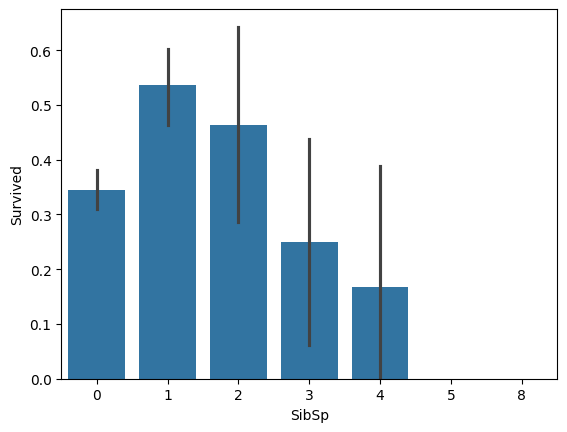

In [91]:
sns.barplot(x = 'SibSp', y = 'Survived', data = train_set)

for i in range(5):
    print(f"Percentage of SibSp = {i} who survived: ", train_set['Survived'][train_set['SibSp'] == i].value_counts(normalize = True)[1]*100)

- people with more siblings or spouses aboard were less likely to survive.

## Embarked :

<Figure size 800x600 with 0 Axes>

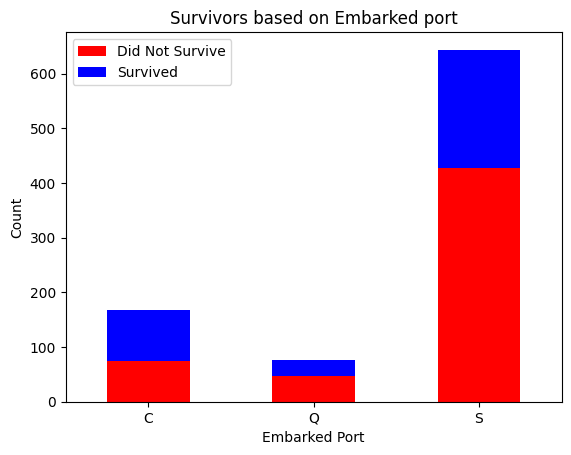

In [92]:
# Grouping data by 'Embarked' and 'Survived', and calculating the count of passengers
survivors_by_embarked = train_set.groupby(['Embarked', 'Survived']).size().unstack()

# Plot
plt.figure(figsize = (8,6))
survivors_by_embarked.plot(kind = 'bar', stacked = 'True', color = ['red', 'blue'])
plt.title('Survivors based on Embarked port')
plt.xlabel('Embarked Port')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.legend(['Did Not Survive', 'Survived'], loc = 'upper left')
plt.show()

In [93]:
# Assuming df_train contains the necessary data

# Count survivors based on embarked port
survived_by_embarked = train_set[train_set['Survived'] == 1]['Embarked'].value_counts()
print("Survived based on embarked port:")
print(survived_by_embarked)
print("-------------------------------------")
# Count non-survivors based on embarked port
non_survived_by_embarked = train_set[train_set['Survived'] == 0]['Embarked'].value_counts()
print("Non Survived based on embarked port:")
print(non_survived_by_embarked)

Survived based on embarked port:
Embarked
S    217
C     93
Q     30
Name: count, dtype: int64
-------------------------------------
Non Survived based on embarked port:
Embarked
S    427
C     75
Q     47
Name: count, dtype: int64


- Mostly people survived of S = Southampton
- MOstly people non survived also S = Southampton 

## Fare :

In [94]:
# scatter plot age and fare base on survived in plotly
fig = px.scatter(train_set, x = 'Age', y = 'Fare', color = 'Survived', title = 'Age vs Fare')
fig.show()

# Check Missing Values :

<Axes: >

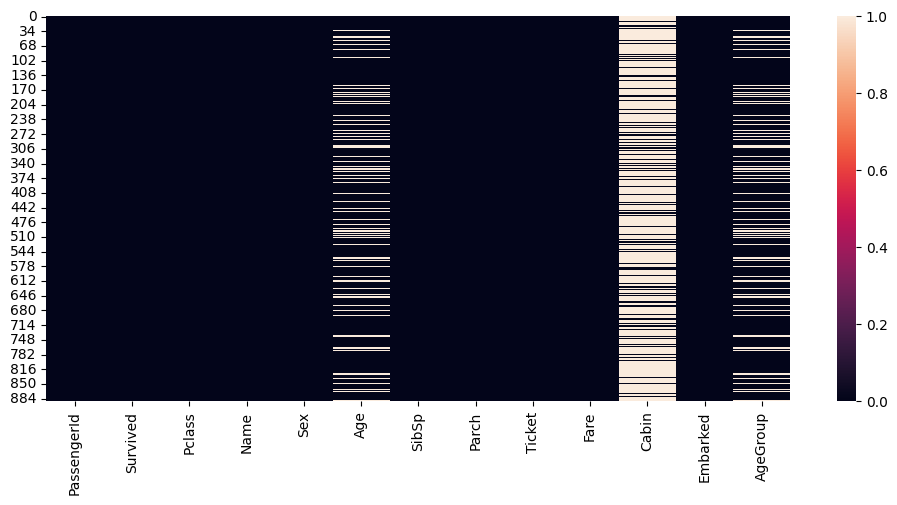

In [95]:
# check null values of train data by graphically
plt.figure(figsize=(12,5))
sns.heatmap(train_set.isnull())

<Axes: >

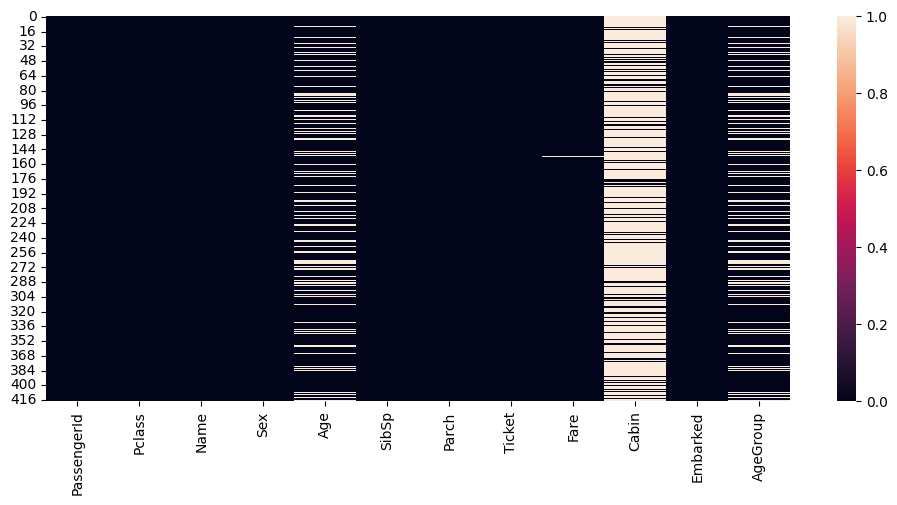

In [96]:
# check null values of test data by graphically
plt.figure(figsize=(12,5))
sns.heatmap(test_set.isnull())

In [97]:
train_set.isnull().sum().sort_values(ascending = False)

Cabin          687
Age            177
AgeGroup       177
Embarked         2
PassengerId      0
Sex              0
Name             0
Pclass           0
Survived         0
Ticket           0
Parch            0
SibSp            0
Fare             0
dtype: int64

In [98]:
# check null values in test data by using pandas
test_set.isnull().sum().sort_values(ascending=False)

Cabin          327
Age             86
AgeGroup        86
Fare             1
Sex              0
Name             0
Pclass           0
PassengerId      0
Ticket           0
Parch            0
SibSp            0
Embarked         0
dtype: int64

In [99]:
# percentage of null values in train set
percentage = (train_set.isnull().sum().sort_values(ascending = False)) / len(train_set) * 100
print(percentage)

Cabin          77.104377
Age            19.865320
AgeGroup       19.865320
Embarked        0.224467
PassengerId     0.000000
Sex             0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Ticket          0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
dtype: float64


In [100]:
# percentage of null values in test set
percentage = (test_set.isnull().sum().sort_values(ascending = False)) / len(test_set) * 100
print(percentage)

Cabin          78.229665
Age            20.574163
AgeGroup       20.574163
Fare            0.239234
Sex             0.000000
Name            0.000000
Pclass          0.000000
PassengerId     0.000000
Ticket          0.000000
Parch           0.000000
SibSp           0.000000
Embarked        0.000000
dtype: float64


# Impute Missing Values :

In [101]:
missing_data_cols = train_set.isnull().sum()[train_set.isnull().sum() > 0].index.tolist()
print("Columns  of missing values in train data :",missing_data_cols)

Columns  of missing values in train data : ['Age', 'Cabin', 'Embarked', 'AgeGroup']


In [102]:
# Cabin column  in train data have highest missing values so removed
train_set.drop('Cabin', axis=1, inplace = True)

- Cabin has more than 50% missing values in train data so removed from data

In [103]:
# Define Features
categorical_features = ['Embarked', 'AgeGroup']
numeric_features = ['Age']

In [104]:
# Create Transformers

numeric_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('OneHot', OneHotEncoder(handle_unknown = 'ignore'))
])

In [105]:
# Combine Transformer into a single preprocessor

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Train_Test_Split :

In [106]:
X = train_set.drop('Survived', axis=1)
y = train_set['Survived']

In [107]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [108]:
model = Pipeline( steps = [
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter = 1000))
])

In [109]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('OneHot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'AgeGroup'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [111]:
y_pred = model.predict(X_val)

In [114]:
accuracy = accuracy_score(y_val, y_pred)
print(f'Accuracy : {accuracy :4f}')

Accuracy : 0.620112


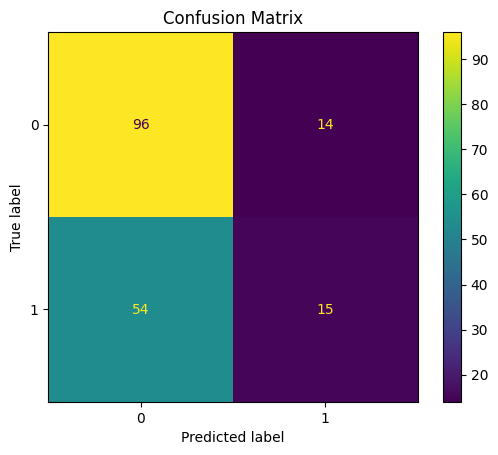

In [119]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
plt.title("Confusion Matrix")
plt.show()

In [121]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.87      0.74       110
           1       0.52      0.22      0.31        69

    accuracy                           0.62       179
   macro avg       0.58      0.55      0.52       179
weighted avg       0.59      0.62      0.57       179

